# Team: Alexandro Galvez-Vega and Victor Neyra
# Class: CAP 5625-042 Computational Foundations Of AI
# Professor: Michael DeGiorgio

In [30]:
#Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

# Deliverables Are Located Below
# __________________________________________________________________
# __________________________________________________________________


In [31]:
#The previous assignment was used as a template
#Similar early logic exists
#Here, we are temporarily turning the csv data into a data frame

filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

#This dataframe is quickly split between the features that will be used for x

x_features_df = advertising_df.copy(deep = True)


#Our goal is to determine credit card balance which is separated into its own df here

y_features_df = x_features_df.pop("Balance") 

In [32]:

#In this part the categorical columns are converted to allow them to be used for the upcoming alogirthms
x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)

In [33]:
#This simply shows that the columns were converted and the original columns are gone
#Earlier the df was place into a deep copy of the original information so the original form exists too
x_features_df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender_Male,Married_Yes,Student_Yes
0,14.891,3606,283,2,34,11,1,1,0
1,106.025,6645,483,3,82,15,0,1,1
2,104.593,7075,514,4,71,11,1,0,0
3,148.924,9504,681,3,36,11,0,0,0
4,55.882,4897,357,2,68,16,1,1,0


In [34]:

#For the purposes of the assignment, we are using ridge regression
#which requires standardization of the data
y_standardized = y_features_df - y_features_df.mean()


##The TA pointed out that encoded features need to be standardized as well
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()





In [35]:
#In the previous assignment a column of 1s was created for Beta 0
#This time it is not necessary
x_standardized_add1 = X_standardized




#This time the starting learning rate is 10 ^ -5
learning_rate_alpha = 10 ** -5

#This is the information of our penalty term lambda
tuning_parameter = 10 ** -2
tuning_parameters_set = [10**-2,10**-1,10**0,10**1,10**2,10**3,10**4,10**5,10**6]
#tuning_parameter = 0


k_fold = 5  

#We get the total number of observations involved
observations_N = len(X_standardized)

#We note the total number of features too
feature_total_p = len(x_standardized_add1.columns)

#The dataframes are converted to numpy arrays to allow for the matrix math that is going to be involved
X = x_standardized_add1.to_numpy()



y = y_standardized.to_numpy()

#This is represents the observation to fold split for the k fold operations
k_N_Splits = observations_N // k_fold 


#Like before, it must be noted that a standardized coefficients are always in a range between -1 and +1"
#Therefore, we use this information again for assignment 2
#Random is once again used to give us a random initial beta, -1 and 1 are used as a range
#This is relevant for the iteration loop that will occur in the later logic of the code

#initial_beta = np.random.uniform(-1, 1, feature_total_p)
initial_beta = np.random.uniform(-1, 1, feature_total_p)


In [36]:
#This is a intermediary holder for the beta information

intermediary_beta = initial_beta

#Vector param beta will act as the final ideal once the loop logic is exited
#This is primariy here to keep the logic easy to follow nd concise

#Placeholder until final values are estbalished
vector_param_beta = initial_beta

#variable to keep track of all beta resuls for graphing
record_of_v_beta = []


#variable to keep track of the cost history for graphing
record_of_cost = []

#The iteration loop size is set to 100,000 this time around

iter_loops = 1_000

b_k_set = np.sum(X**2)
beta_loop_length = len(intermediary_beta)

In [37]:
def tuning_cv_loop_elastic(elastic_tp):
    #This wil hold all the cv error and beta scores 
    cross_validation_account_final = []
    vector_parameter_beta_final = []

    cross_validation_beta_account_final = []
    #This loop is to go through each penalty value
    for current_tuning_paremeter in tuning_parameters_set:
        #This is the current penalty term
        tuning_parameter = current_tuning_paremeter
        #The observations are randomly reorganized
        random_reorder = np.random.permutation(observations_N)
        #This will track the immedia cv errors as we parse through each fold in the 5 k old operation
        cross_validation_account = []
        #This will hold beta
        cross_validation_beta_account = []
        
        #This is to loop through all the folds with the current penalty value in place
        for fold in range(k_fold):
            
            #This is a reset for the beta for each iteration
            intermediary_beta = initial_beta.copy()

            #This logic is for observation placement after the random reorganization
            #A section of the observations is taken based on the current fold in play and the split size
            beg_index = fold * k_N_Splits
            end_index = (fold + 1) * k_N_Splits
            beg_to_end_indexes = np.arange(beg_index, end_index)


            #The observations for the validation part of the cross validation loop are set in place here
            validation_unit = random_reorder[beg_to_end_indexes]
            X_validation_set = X[validation_unit]
            y_validation_set = y[validation_unit]
            
            #The observations for the training part of the cross validation loop are set in place here
            X_training_set = np.delete(X, validation_unit, axis=0)
            y_training_set = np.delete(y, validation_unit, axis=0)

            
            #This loop exists for the batch gradient descent logic
            for iter_c in range(iter_loops):

                X_training_transposed = np.transpose(X_training_set)

                for k_current in range(beta_loop_length):
                    X_k_current = X_training_set[:,k_current]
                    a_k_p1 = y_training_set - X_training_set.dot(intermediary_beta) 
                    a_k_p2 = a_k_p1 + (X_k_current * intermediary_beta[k_current])
                    a_k_set = X_training_transposed[k_current].dot(a_k_p2)
                    

                    if a_k_set < - ((current_tuning_paremeter) * (1-elastic_tp)) / 2:
                        intermediary_beta[k_current] = (a_k_set + ((current_tuning_paremeter * (1 - elastic_tp))/2))/ (b_k_set + (current_tuning_paremeter * elastic_tp))
                    elif a_k_set > ((current_tuning_paremeter) * (1-elastic_tp)) / 2:
                        intermediary_beta[k_current] = (a_k_set - ((current_tuning_paremeter * (1 - elastic_tp))/2))/ (b_k_set + (current_tuning_paremeter * elastic_tp))
                    else:
                        intermediary_beta[k_current] = 0

                # #X transposed is set for future equation use
                # X_training_transposed = np.transpose(X_training_set)
                
                # #The equation from assignment 2 is chunked out between the next three lines of code
                # #to adjust the beta values, one small difference include in terms of arrangement
                # update_pv_p1 = X_training_transposed.dot(y_training_set - X_training_set.dot(intermediary_beta))

                
                # update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
                # intermediary_beta += 2 * learning_rate_alpha * update_pv_p2
            
            #Outside of the loop the y output is predicted based on the validation set and beta provided
            y_vaidation__set_predicted = X_validation_set.dot(intermediary_beta)
            
            #a validation error score is marked based on the information
        
            validation_error = np.sum((y_validation_set - y_vaidation__set_predicted)**2) / len(y_validation_set)
            
            #The information is appended for future use
            cross_validation_account.append(validation_error)
            
            cross_validation_beta_account.append(intermediary_beta)
            #print(validation_error)
        #After the cross validation loop is done the cv error is achieved by getting the mean
        cross_validation_error = np.mean(cross_validation_account)
        #The cv error from using the current penalty value is appended to find the lowest cross validation score later
        cross_validation_account_final.append(cross_validation_error)
        #Beta is marked too
        vector_parameter_beta_final.append(intermediary_beta)
        #The mean beta from the cv loop is marked too
        cross_validation_beta_account_final.append(np.mean(cross_validation_beta_account, axis=0))
        #print(cross_validation_error)
    print(cross_validation_account_final)

    return cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final










In [38]:
elastic_tuning_parameter_set = [0, .2, .4, .6, .8,  1]
cross_validation_account_final=[]
vector_parameter_beta_final=[]
cross_validation_beta_account_final=[]

etp_cross_validation_account_final = []
etp_vector_parameter_beta_final = []
etp_cross_validation_beta_account_final = []
for elastic_tuning_parameter in elastic_tuning_parameter_set:
    elastic_tp = elastic_tuning_parameter
    cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final = tuning_cv_loop_elastic(elastic_tp)
    etp_cross_validation_account_final.append(cross_validation_account_final)
    etp_vector_parameter_beta_final.append(vector_parameter_beta_final)
    etp_cross_validation_beta_account_final.append(cross_validation_beta_account_final)


[158919.90022260166, 158734.97662358763, 158412.43864852918, 158756.09651577356, 158800.2708068399, 158664.49948040303, 160724.83541431432, 181191.583364606, 210849.779775]
[158969.79989848915, 158391.0716923272, 158628.7688551105, 159214.42207431918, 158908.9769289231, 161100.05441406518, 175830.42337222616, 204762.25208517746, 210849.779775]
[158550.6573358233, 159196.67515239897, 158541.4088904042, 158509.62983005523, 158805.05967445282, 162890.69913058405, 183895.04671718704, 207064.47463023098, 210849.77977500003]
[158787.20080889767, 158547.84382087202, 158726.68578609038, 158637.76290455207, 159596.23676821598, 164726.9499058813, 188990.76504139943, 207892.17914752977, 210849.779775]
[158485.5081559413, 158625.62303971144, 159005.00301778392, 158590.22625024876, 159938.31526898436, 166370.2518173453, 192046.11264405312, 208310.4042257715, 210798.46544351446]
[158848.1900778169, 158397.57613779153, 158405.0826401017, 159024.34660174217, 160085.02842514229, 168210.8844836927, 1945

In [50]:
print(etp_vector_parameter_beta_final[0])

[array([14.59139295, 30.80078636, 30.89721703,  1.0411506 , -1.65800392,
        0.17796586, -1.91160731, -0.41856817,  9.27574861]), array([15.44908841, 31.7214516 , 31.90714943,  4.53990843,  0.22128722,
        1.68020785, -0.4530791 , -1.42913503, 10.95451802]), array([14.78766987, 30.57685652, 30.6685224 ,  3.88736126, -0.83958155,
        0.89215469, -1.62070353,  0.64883641, 10.2980569 ]), array([15.51410098, 32.24189575, 32.30142895,  4.42860937,  0.82091126,
        1.32135103, -1.84788413,  0.64629476,  9.33522706]), array([12.72452707, 29.56732163, 29.5422713 ,  2.88432833,  1.20166412,
       -0.72601076, -0.05382433, -0.06621459,  9.54019963]), array([14.49223694, 30.75951548, 30.81282544,  3.51189257, -0.61354726,
       -0.73196194, -1.76546961,  0.61076098,  9.6949537 ]), array([12.19979773, 29.86034028, 30.08646703,  3.75352173,  0.        ,
        0.        ,  0.        ,  0.        ,  7.9985854 ]), array([ 3.46218967, 19.8667149 , 19.96097647,  0.        ,  0.      

In [51]:
print(etp_vector_parameter_beta_final[1])

[array([15.0663702 , 31.66700167, 31.71025431,  2.93165157,  0.29893464,
       -0.83880367, -1.26086201, -1.99757847,  9.57425136]), array([15.64359185, 32.18747007, 32.29828935,  2.29933185,  0.9004003 ,
       -1.71977375,  0.3464385 , -0.06274346, 10.21456478]), array([14.23468677, 31.04818208, 31.09478852,  1.582541  , -0.62512853,
       -0.58535538,  0.47642314, -1.17547973,  9.51185971]), array([14.94249447, 31.90992968, 31.83753502,  1.17781804,  1.31108437,
        0.49153092, -2.10896976, -2.27736947, 12.58627954]), array([14.95337631, 32.07450629, 32.24562903,  3.72970583, -1.52416332,
        0.25848563, -0.26573894, -0.89058744, 12.43123658]), array([ 1.48525287e+01,  3.11343670e+01,  3.12939832e+01,  3.22244285e+00,
        3.38926776e-01, -1.02339740e+00, -1.13976725e-02, -1.31718710e+00,
        8.76941668e+00]), array([10.20105714, 20.71971379, 20.80944612,  1.81912919,  0.        ,
        0.        ,  0.        , -0.05038549,  6.75936141]), array([1.0479031 , 3.5744

In [52]:
print(etp_vector_parameter_beta_final[2])

[array([ 1.53138119e+01,  3.23991413e+01,  3.24611378e+01,  2.95073289e+00,
       -1.97176146e+00,  2.44712236e-02, -1.04020789e+00,  7.06438246e-01,
        8.96030310e+00]), array([12.47262142, 29.9225203 , 29.86469918,  2.21557345, -0.03972945,
        1.16868738,  0.87200816, -1.20375024, 11.49225171]), array([15.21878436, 32.54783289, 32.62478645,  3.6630274 , -0.81614216,
       -1.2928081 ,  1.25891652, -1.75616924, 10.5987071 ]), array([13.83227162, 30.60737657, 30.51759116,  1.76186378,  0.17788792,
       -1.0566205 , -1.34429886,  0.63607049, 10.26091029]), array([ 1.42546431e+01,  3.03499743e+01,  3.05703500e+01,  2.04230951e+00,
       -1.23700775e+00, -6.26707315e-01, -1.58345350e+00,  2.32745149e-03,
        1.01310765e+01]), array([12.5367199 , 27.98203148, 28.09682468,  4.00142912, -0.53347897,
        0.2240295 , -0.4825702 , -0.4277073 , 10.24721805]), array([ 7.65879166, 15.71050972, 15.71799105,  1.49487488, -0.44457447,
        0.        , -0.06179989,  0.       

# __________________________________________________________________
# __________________________________________________________________

In [40]:
print(tuning_parameters_set)

[0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]


In [65]:
def coeffecientsvptp(current_vector_param_b, graph_title):
    
    current_vector_param_b = np.array(current_vector_param_b)
    
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]

    plt.figure(figsize=(10, 6))

    #Using the beta values found at each penalty parameter a graph is made. Labels show a beta for each specific column
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,0], label="Income")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,1], label="Limit")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,2], label="Rating")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,3], label="Cards")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,4], label="Education")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,5], label="Gender")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,6], label="Married")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,7], label="Student")
    plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Coefficient Values')
    #plt.title('Standardized Coefficients Against Penalty Tuning Parameters')
    plt.title(graph_title)
    plt.legend(loc=1)
    plt.show()

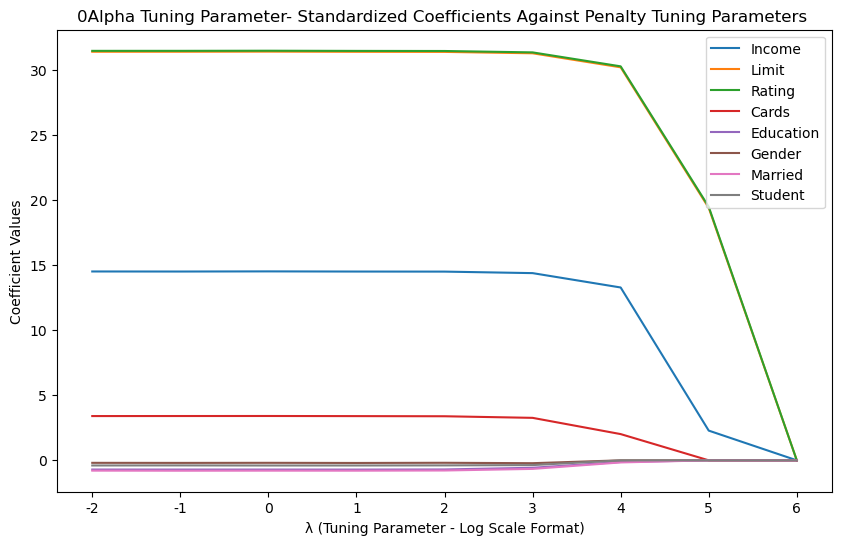

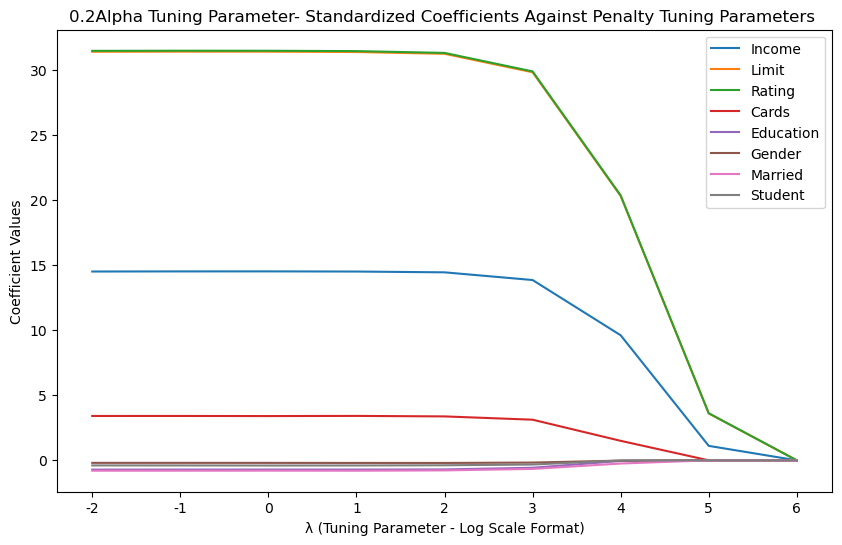

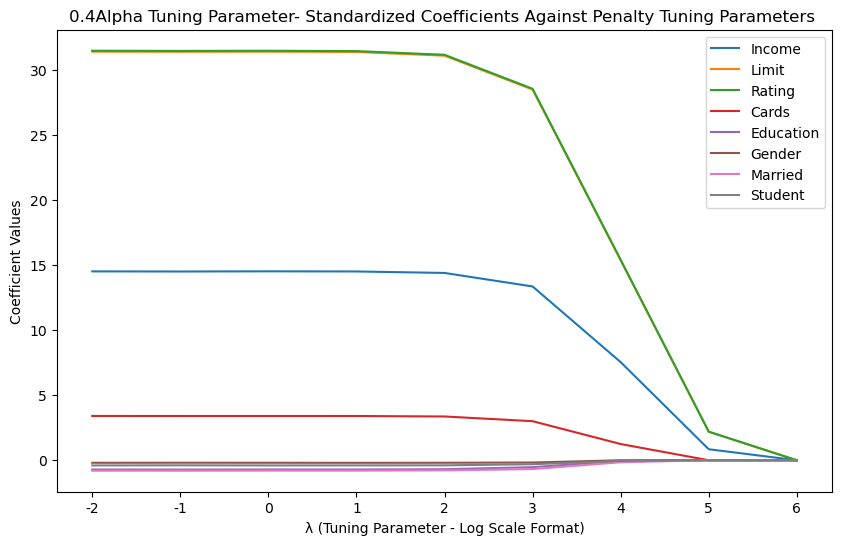

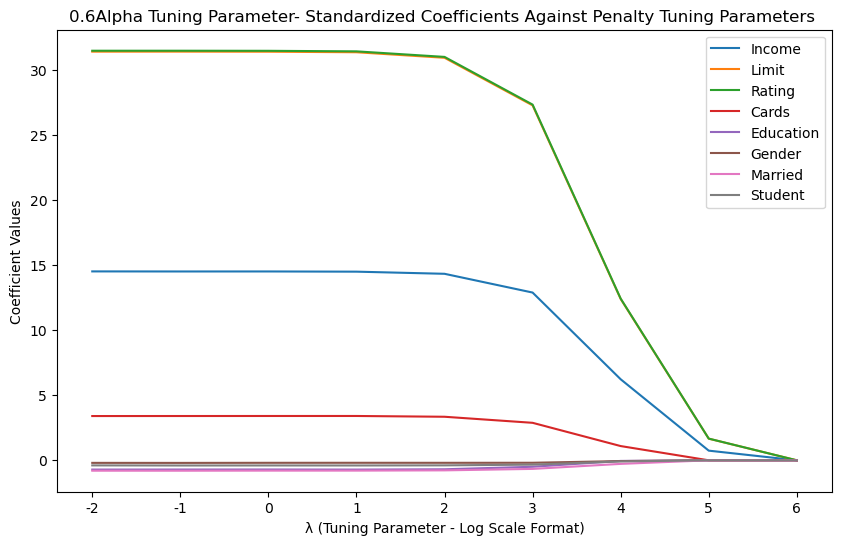

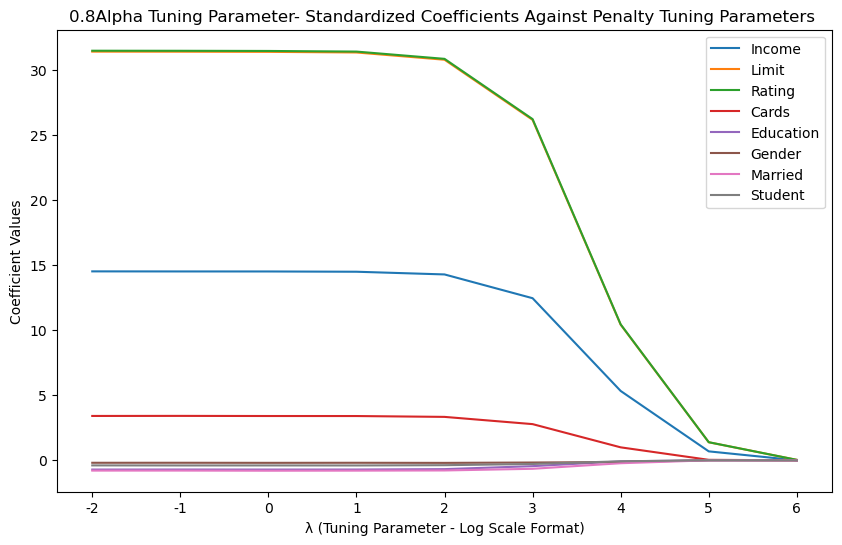

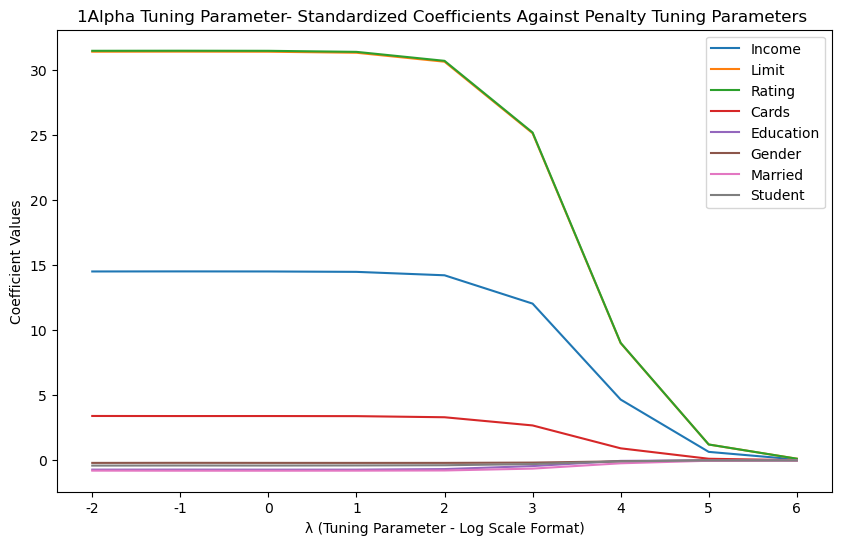

In [69]:
for current_graph_etp in range(len(elastic_tuning_parameter_set)):
    current_vector_param_b = etp_cross_validation_beta_account_final[current_graph_etp]
    
    graph_title = str(elastic_tuning_parameter_set[current_graph_etp]) + "Alpha Tuning Parameter- Standardized Coefficients Against Penalty Tuning Parameters "
    coeffecientsvptp(current_vector_param_b,  graph_title)
    

In [61]:
# import matplotlib.pyplot as plt

# def coeffecientsvptp(beta_values, tuning_parameters_set):
#     tp_log_set = np.log10(tuning_parameters_set)

#     plt.figure(figsize=(10, 6))

#     # Plot each coefficient line for a specific alpha's beta values
#     plt.semilogx(tuning_parameters_set, beta_values[:, 0], label="Income")
#     plt.semilogx(tuning_parameters_set, beta_values[:, 1], label="Limit")
#     plt.semilogx(tuning_parameters_set, beta_values[:, 2], label="Rating")
#     plt.semilogx(tuning_parameters_set, beta_values[:, 3], label="Cards")
#     plt.semilogx(tuning_parameters_set, beta_values[:, 4], label="Education")
#     plt.semilogx(tuning_parameters_set, beta_values[:, 5], label="Gender")
#     plt.semilogx(tuning_parameters_set, beta_values[:, 6], label="Married")
#     plt.semilogx(tuning_parameters_set, beta_values[:, 7], label="Student")

#     # Adjust axis and labels for clarity
#     plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
#     plt.ylabel('Coefficient Values')
#     plt.title('Elastic Net Coefficients by Tuning Parameters')
#     plt.legend(loc=1)
#     plt.show()

Plotting for alpha = 0


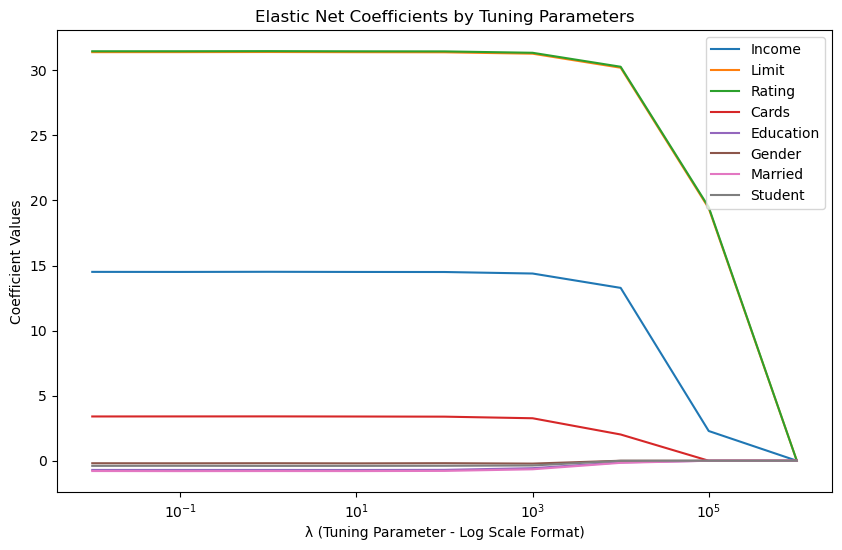

Plotting for alpha = 0.2


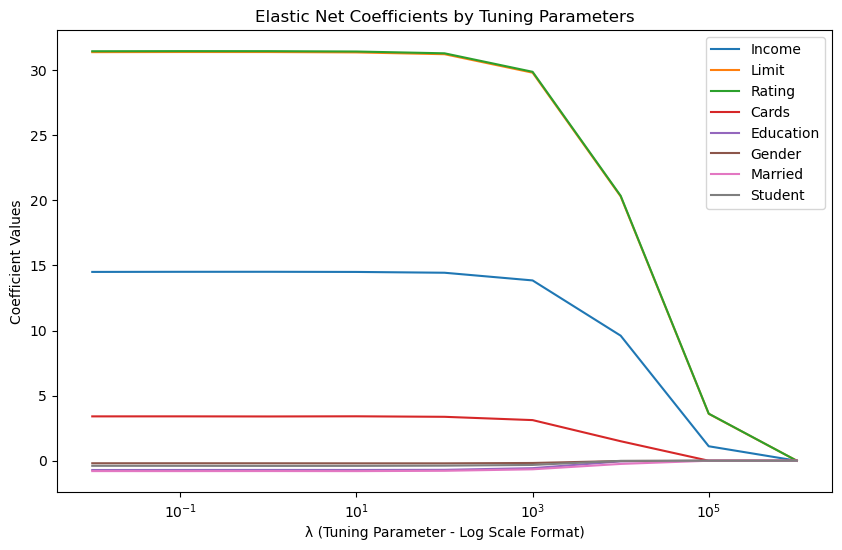

Plotting for alpha = 0.4


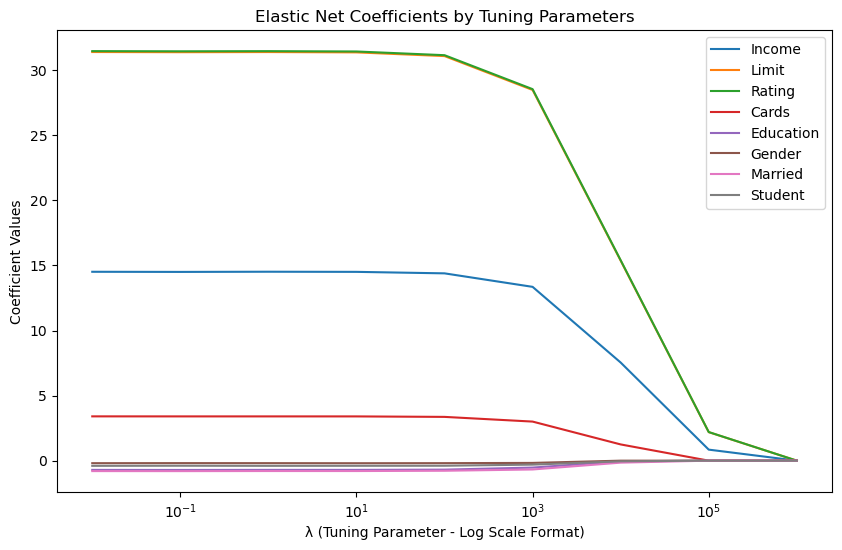

Plotting for alpha = 0.6


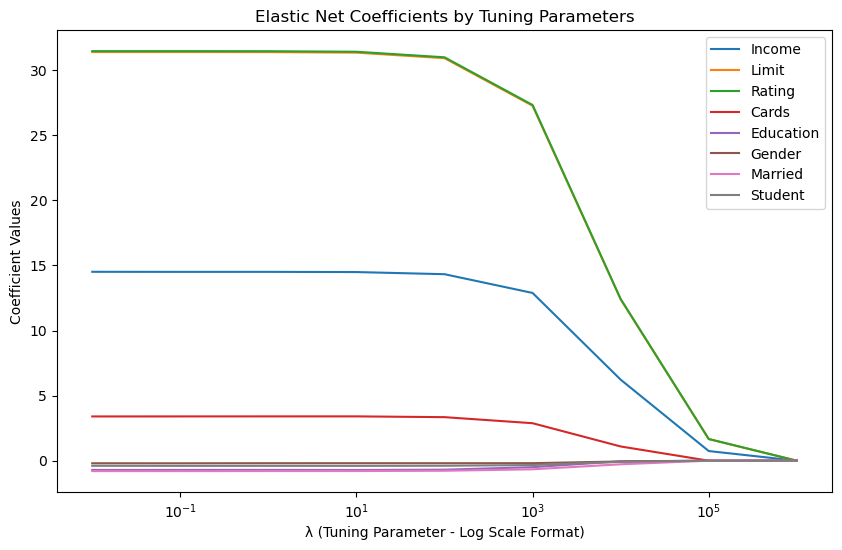

Plotting for alpha = 0.8


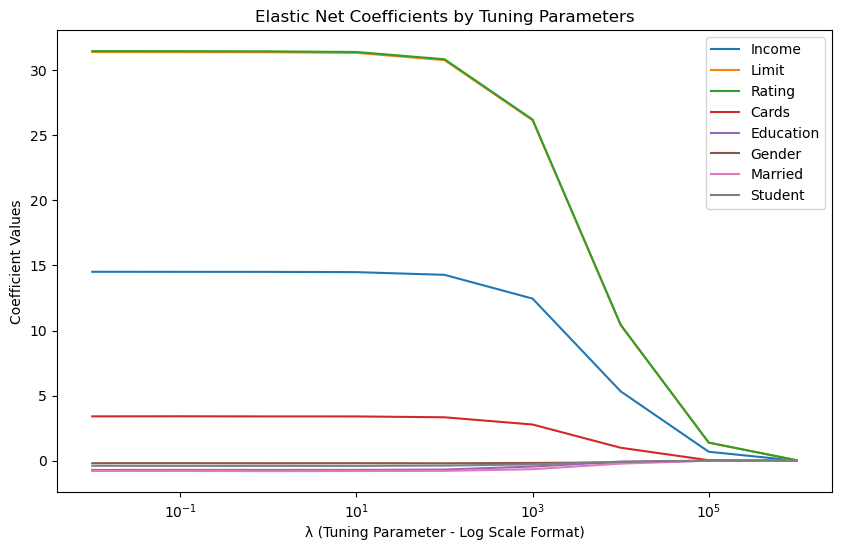

Plotting for alpha = 1


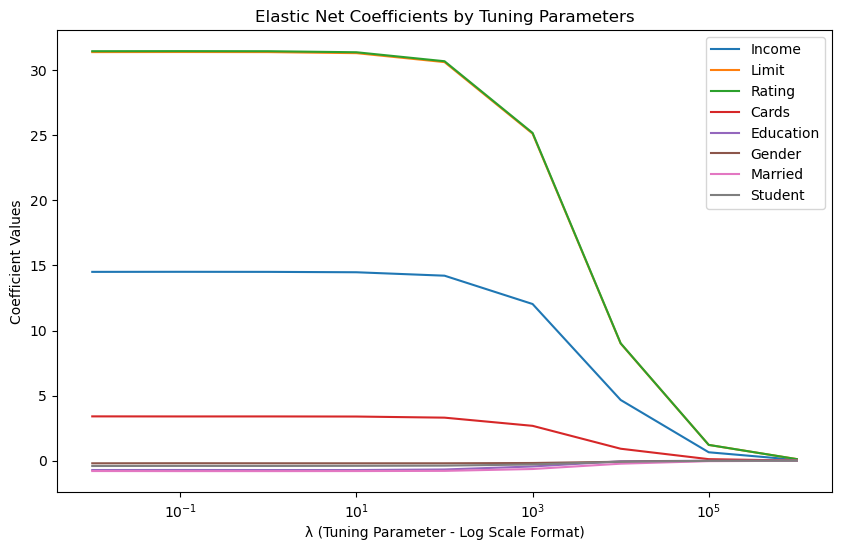

In [62]:
# for i, alpha_beta_values in enumerate(etp_cross_validation_beta_account_final):
#     print(f"Plotting for alpha = {elastic_tuning_parameter_set[i]}")
#     coeffecientsvptp(np.array(alpha_beta_values), tuning_parameters_set)

# __________________________________________________________________
# __________________________________________________________________

In [ ]:
#Getting image
image_load = "a2dev2.png"

# # Display the image
Image(filename=image_load) 

In [ ]:
#This graph shows the cross validation error scores across all of the penalty terms

plt.figure(figsize=(10, 6))
plt.semilogx(tuning_parameters_set, cross_validation_account_final, 'bo-')
plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Cross-Validation Error Scores')
plt.title('Cross-Validation Error Scores Against Penalty Parameters')
plt.show()

# __________________________________________________________________
# __________________________________________________________________

In [ ]:
#Getting image
image_load = "a2dev3.png"

# # Display the image
Image(filename=image_load) 

In [ ]:
#This gets the lowest cross validation error score from the list gathered
lowest_cross_validation_error = min(cross_validation_account_final)
print("The lowest cross-validation error score achieved: " + str(lowest_cross_validation_error))

In [ ]:
#This lowest cross validation error score is used to get the the lambda parameter used to achieve this score
tuning_parameter_lowest_cv = 0
for i in range(len(cross_validation_account_final)):
    if cross_validation_account_final[i] == lowest_cross_validation_error:
        tuning_parameter_lowest_cv = tuning_parameters_set[i]

print("The lambda parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cv))
#print(tuning_parameter_lowest_cv)


# __________________________________________________________________
# __________________________________________________________________

In [ ]:
#Getting image
image_load = "a2dev4.png"

# # Display the image
Image(filename=image_load) 

In [26]:
#This is a simpler version of the earlier code without the penalty parameter loop of the k fold loop now that an
#optimal lambda value has been discovered
#all of the observations are used for a final y prediction
#The mse and final beta is found too
cross_validation_account_final = []
vector_parameter_beta_final = []

cross_validation_beta_account_final = []


tuning_parameter = tuning_parameter_lowest_cv
random_reorder = np.random.permutation(observations_N)
intermediary_beta = initial_beta.copy()
X_final = X[random_reorder]
y_final = y[random_reorder]

for iter_c in range(iter_loops):
        #lkmlkml
        X_final_transposed = np.transpose(X_final)
        #The math here can be found from a1
        update_pv_p1 = X_final_transposed.dot(y_final - X_final.dot(intermediary_beta))
        #update_pv_p2 = ((tuning_parameter * intermediary_beta) - update_pv_p1)
        update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
        intermediary_beta += 2 * learning_rate_alpha * update_pv_p2

y_final_predicted = X_final.dot(intermediary_beta)
mean_squared_error = np.sum((y_final - y_final_predicted)**2) / len(y_final)
final_vector_param_beta = intermediary_beta


In [ ]:
#This prints out the beta parameters based on the model that used all the observation data
#The values are rounded to the fourth decimal point
print("9 Best Fit Model Parameters Based On Tuning Parameter That Produced The Lowest Cross-Validation Error Score: ")
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes


print("Income: " + str(round(final_vector_param_beta[0], 4)))
print("Limit: " + str(round(final_vector_param_beta[1], 4)))
print("Rating: " + str(round(final_vector_param_beta[2], 4)))
print("Cards: " + str(round(final_vector_param_beta[3], 4)))
print("Age: " + str(round(final_vector_param_beta[4], 4)))
print("Education: " + str(round(final_vector_param_beta[5], 4)))
print("Gender: " + str(round(final_vector_param_beta[6], 4)))
print("Married: " + str(round(final_vector_param_beta[7], 4)))
print("Student: " + str(round(final_vector_param_beta[8], 4)))


In [28]:
# __________________________________________________________________
# __________________________________________________________________

In [ ]:
#Getting image
image_load = "a2dev5.png"

# # Display the image
Image(filename=image_load) 

#The codebase in its entirty without the value results is located below.

################################
################################
################################
################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image


# In[4]:



image_load = "CAP5625_A2_Page_1.jpg"


Image(filename=image_load) 


# In[6]:



image_load = "CAP5625_A2_Page_3.jpg"


Image(filename=image_load) 


# In[7]:



image_load = "CAP5625_A2_Page_4.jpg"


Image(filename=image_load) 


# In[8]:



image_load = "CAP5625_A2_Page_5.jpg"


Image(filename=image_load) 


# In[5]:



image_load = "CAP5625_A2_Page_2.jpg"


Image(filename=image_load) 




# In[3]:


filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)



x_features_df = advertising_df.copy(deep = True)




y_features_df = x_features_df.pop("Balance") 


# In[4]:



x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)


# In[5]:


x_features_df.head()


# In[7]:




y_standardized = y_features_df - y_features_df.mean()

X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()




# In[8]:


x_standardized_add1 = X_standardized


learning_rate_alpha = 10 ** -5

tuning_parameter = 10 ** -2
tuning_parameters_set = [10**-2,10**-1,10**0,10**1,10**2,10**3,10**4]



k_fold = 5  


observations_N = len(X_standardized)


feature_total_p = len(x_standardized_add1.columns)


X = x_standardized_add1.to_numpy()



y = y_standardized.to_numpy()


k_N_Splits = observations_N // k_fold 



initial_beta = np.random.uniform(-1, 1, feature_total_p)


# In[9]:



intermediary_beta = initial_beta



vector_param_beta = initial_beta


record_of_v_beta = []


record_of_cost = []


iter_loops = 100_000


# In[10]:




cross_validation_account_final = []
vector_parameter_beta_final = []

cross_validation_beta_account_final = []

for current_tuning_paremeter in tuning_parameters_set:
    tuning_parameter = current_tuning_paremeter
    random_reorder = np.random.permutation(observations_N)
    cross_validation_account = []
    
    cross_validation_beta_account = []
    for fold in range(k_fold):
        intermediary_beta = initial_beta.copy()


        beg_index = fold * k_N_Splits
        end_index = (fold + 1) * k_N_Splits
        beg_to_end_indexes = np.arange(beg_index, end_index)



        validation_unit = random_reorder[beg_to_end_indexes]
        X_validation_set = X[validation_unit]
        y_validation_set = y[validation_unit]

        X_training_set = np.delete(X, validation_unit, axis=0)
        y_training_set = np.delete(y, validation_unit, axis=0)


        for iter_c in range(iter_loops):


            X_training_transposed = np.transpose(X_training_set)

            update_pv_p1 = X_training_transposed.dot(y_training_set - X_training_set.dot(intermediary_beta))

            update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
            intermediary_beta += 2 * learning_rate_alpha * update_pv_p2

        y_vaidation__set_predicted = X_validation_set.dot(intermediary_beta)

        validation_error = np.sum((y_validation_set - y_vaidation__set_predicted)**2) / len(y_validation_set)
        cross_validation_account.append(validation_error)
        
        cross_validation_beta_account.append(intermediary_beta)


    cross_validation_error = np.mean(cross_validation_account)
    cross_validation_account_final.append(cross_validation_error)
    vector_parameter_beta_final.append(intermediary_beta)
    
    cross_validation_beta_account_final.append(np.mean(cross_validation_beta_account, axis=0))

print(cross_validation_account_final)








# In[11]:


print(vector_parameter_beta_final)


# In[12]:


vector_parameter_beta_final_means = np.mean(vector_parameter_beta_final)




# In[10]:



image_load = "a2dev1.png"

Image(filename=image_load) 


# In[13]:


vector_parameter_beta_final_np = np.array(vector_parameter_beta_final)

plt.figure(figsize=(10, 6))


plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,0], label="Income")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,1], label="Limit")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,2], label="Rating")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,3], label="Cards")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,4], label="Education")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,5], label="Gender")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,6], label="Married")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,7], label="Student")
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Coefficient Values')
plt.title('Standardized Coefficients Against Fine Tuning Parameters')
plt.legend()
plt.show()


# In[14]:


cross_validation_beta_account_final_np = np.array(cross_validation_beta_account_final)

plt.figure(figsize=(10, 6))


plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,0], label="Income")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,1], label="Limit")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,2], label="Rating")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,3], label="Cards")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,4], label="Education")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,5], label="Gender")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,6], label="Married")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,7], label="Student")
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Coefficient Values')
plt.title('Standardized Coefficients Against Fine Tuning Parameters')
plt.legend()
plt.show()




# In[11]:



image_load = "a2dev2.png"


Image(filename=image_load) 


# In[15]:


plt.figure(figsize=(10, 6))
plt.semilogx(tuning_parameters_set, cross_validation_account_final, 'bo-')
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Cross-Validation Error Scores')
plt.title('Cross-Validation Error Scores Against Fine Tuning Parameters')
plt.show()




# In[12]:



image_load = "a2dev3.png"


Image(filename=image_load) 


# In[13]:


lowest_cross_validation_error = min(cross_validation_account_final)
print("The lowest cross-validation error score achieved: " + str(lowest_cross_validation_error))


# In[17]:


tuning_parameter_lowest_cv = 0
for i in range(len(cross_validation_account_final)):
    if cross_validation_account_final[i] == lowest_cross_validation_error:
        tuning_parameter_lowest_cv = tuning_parameters_set[i]

print("The fine tuning parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cv))

# In[14]:



image_load = "a2dev4.png"


Image(filename=image_load) 


# In[18]:



cross_validation_account_final = []
vector_parameter_beta_final = []

cross_validation_beta_account_final = []


tuning_parameter = tuning_parameter_lowest_cv
random_reorder = np.random.permutation(observations_N)
intermediary_beta = initial_beta.copy()
X_final = X[random_reorder]
y_final = y[random_reorder]

for iter_c in range(iter_loops):

        X_final_transposed = np.transpose(X_final)

        update_pv_p1 = X_final_transposed.dot(y_final - X_final.dot(intermediary_beta))

        update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
        intermediary_beta += 2 * learning_rate_alpha * update_pv_p2

y_final_predicted = X_final.dot(intermediary_beta)
mean_squared_error = np.sum((y_final - y_final_predicted)**2) / len(y_final)
final_vector_param_beta = intermediary_beta


# In[20]:


print("9 Best Fit Model Parameters Based On Tuning Parameter That Produced The Lowest Cross-Validation Error Score: ")



print("Income: " + str(round(final_vector_param_beta[0], 4)))
print("Limit: " + str(round(final_vector_param_beta[1], 4)))
print("Rating: " + str(round(final_vector_param_beta[2], 4)))
print("Cards: " + str(round(final_vector_param_beta[3], 4)))
print("Age: " + str(round(final_vector_param_beta[4], 4)))
print("Education: " + str(round(final_vector_param_beta[5], 4)))
print("Gender: " + str(round(final_vector_param_beta[6], 4)))
print("Married: " + str(round(final_vector_param_beta[7], 4)))
print("Student: " + str(round(final_vector_param_beta[8], 4)))


################################
################################
################################
################################


In [30]:
# __________________________________________________________________
# __________________________________________________________________

In [ ]:
#Getting image
image_load = "a2dev6.png"

# # Display the image
Image(filename=image_load) 

#The codebase in its entirty without the value results is located below.

In [32]:
#libraries that we will be using for the extra credit

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

#Since this is all set in the earlier code, this will all be used again
tuning_parameters_setd6 = tuning_parameters_set



k_foldd6 = k_fold


observations_Nd6 = observations_N


feature_total_pd6 = feature_total_p


Xd6 = x_standardized_add1.to_numpy()



yd6 = y_standardized.to_numpy()

In [33]:
cross_validation_beta_account_finald6 = []
cross_validation_account_finald6 = []

for current_tuning_parameter in tuning_parameters_setd6:
    
    random_reorder = np.random.permutation(observations_Nd6)
    
    
    tuning_parameter = current_tuning_parameter
    
    ridge_d6 = Ridge(alpha = tuning_parameter)
    
    cross_validation_d6 = cross_val_score(ridge_d6, Xd6, yd6, cv= k_foldd6)
    
    cross_validation_accountd6 = []
    
    cross_validation_beta_accountd6 = []
    
    for fold in range(k_foldd6):
        beg_index = fold * k_N_Splits
        end_index = (fold + 1) * k_N_Splits
        beg_to_end_indexes = np.arange(beg_index, end_index)



        validation_unitd6 = random_reorder[beg_to_end_indexes]
        X_validation_setd6 = X[validation_unitd6]
        y_validation_setd6 = y[validation_unitd6]
        
        X_training_setd6 = np.delete(X, validation_unitd6, axis=0)
        y_training_setd6 = np.delete(y, validation_unitd6, axis=0)
        
        ridge_d6 = Ridge(alpha=tuning_parameter)
        
        ridge_d6.fit (X_training_setd6, y_training_setd6)
        cross_validation_beta_accountd6.append(ridge_d6.coef_)
        
        y_validation_set_predictiond6 = ridge_d6.predict(X_validation_setd6)
        validation_errord6 = np.sum((y_validation_setd6 - y_validation_set_predictiond6)**2) / len(y_validation_setd6)
        cross_validation_accountd6.append(validation_errord6)
    
    cross_validation_error = np.mean(cross_validation_accountd6)
    #The cv error from using the current penalty value is appended to find the lowest cross validation score later
    cross_validation_account_finald6.append(cross_validation_error)
    cross_validation_beta_account_finald6.append(np.mean(cross_validation_beta_accountd6, axis=0))
    
        

In [ ]:
cross_validation_beta_account_final_npd6 = np.array(cross_validation_beta_account_finald6)
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes

tp_log_setd6 = [-2,-1,0,1,2,3,4]

plt.figure(figsize=(10, 6))

#Using the beta values found at each penalty parameter a graph is made. Labels show a beta for each specific column
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,0], label="Income")
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,1], label="Limit")
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,2], label="Rating")
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,3], label="Cards")
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,4], label="Education")
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,5], label="Gender")
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,6], label="Married")
plt.semilogx(tuning_parameters_setd6, cross_validation_beta_account_final_npd6[:,7], label="Student")
plt.xticks(ticks=tuning_parameters_setd6, labels=tp_log_setd6)
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Coefficient Values')
plt.title('Standardized Coefficients Against Penalty Tuning Parameters EC Variant')
plt.legend(loc=1)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.semilogx(tuning_parameters_setd6, cross_validation_account_finald6, 'bo-')
plt.xticks(ticks=tuning_parameters_setd6, labels=tp_log_set)
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Cross-Validation Error Scores')
plt.title('Cross-Validation Error Scores Against Penalty Parameters')
plt.show()

In [ ]:
from sklearn.linear_model import RidgeCV

penalty_check_d6 = RidgeCV(alphas = tuning_parameters_setd6, cv= k_foldd6)
penalty_check_d6.fit(Xd6, yd6)

tuning_parameter_optimal_cvd6 = penalty_check_d6.alpha_
print("The optimal penalty parameter according to sklearn: " + str(tuning_parameter_optimal_cvd6))
#This is using sklearn

In [ ]:

lowest_cross_validation_errord6 = min(cross_validation_account_finald6)
print("The lowest cross-validation error score achieved: " + str(lowest_cross_validation_errord6))


tuning_parameter_lowest_cvd6 = 0
for i in range(len(cross_validation_account_finald6)):
    if cross_validation_account_finald6[i] == lowest_cross_validation_errord6:
        tuning_parameter_lowest_cvd6 = tuning_parameters_setd6[i]

print("The lambda parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cvd6))
#Double checking answer

In [37]:
final_ridge_modeld6 = Ridge(alpha=tuning_parameter_lowest_cvd6)
final_ridge_modeld6.fit(Xd6,yd6)
final_vector_param_betad6 = final_ridge_modeld6.coef_

In [ ]:
print("9 Best Fit Model Parameters Based On Tuning Parameter That Produced The Lowest Cross-Validation Error Score: ")
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes


print("Income: " + str(round(final_vector_param_betad6[0], 4)))
print("Limit: " + str(round(final_vector_param_betad6[1], 4)))
print("Rating: " + str(round(final_vector_param_betad6[2], 4)))
print("Cards: " + str(round(final_vector_param_betad6[3], 4)))
print("Age: " + str(round(final_vector_param_betad6[4], 4)))
print("Education: " + str(round(final_vector_param_betad6[5], 4)))
print("Gender: " + str(round(final_vector_param_betad6[6], 4)))
print("Married: " + str(round(final_vector_param_betad6[7], 4)))
print("Student: " + str(round(final_vector_param_betad6[8], 4)))

# Discussion EC
Ultimately, the graphs were very similar to what was captured above and the best fit parameters were very similar in scope. However, where the 6th delivery diverges is with the best lambda parameter that produces the lowest cross validation error score. The answer is one. Originally, above stated .01. This isn't a completely unusual result. The cross validation scores are fairly consistent from 10^-2 to 10^1. There could be some fluctuation between tests. The main different is the influence of the coeffecients (beta values) and at one it is a little bit more streamlined as well. 